### Employee Turnover Modeling (Supervised Learning: Classification)
This project focuses on data preprocessing and feature engineering to uncover critical drivers of employee attrition. We then develop, train, and deploy a machine learning model to predict employee turnover likelihood, leveraging a standard MLOps pipeline for robust and scalable deployment.

###Import Libraries
This cell imports the necessary Python libraries for data manipulation, visualization, and machine learning.

In [51]:
#Call the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

### Mount Google Drive

This cell mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive, such as the `HR_comma_sep.csv` dataset.

In [52]:
#Mount GDrive to access the cloud data file
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Load Data

This cell defines the path to the `HR_comma_sep.csv` file in Google Drive and then uses `pandas` to read the CSV file into a DataFrame named `hr`. The DataFrame is then displayed to show its contents.

In [53]:
#Call the data
hr_data = '/content/gdrive/MyDrive/HR_comma_sep.csv'
hr = pd.read_csv(hr_data)
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


### Create DataFrame and Display Head

This cell creates a new DataFrame `df_hr` from the loaded `hr` DataFrame. It then displays the first few rows of `df_hr` to quickly preview the data structure and content.

In [54]:
#Create the data frame
df_hr = pd.DataFrame(hr)
df_hr.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Step 1: Data Quality Check

This cell performs initial data quality checks. It displays the shape of the DataFrame (number of rows and columns), provides a summary of its information (`.info()`) including data types and non-null counts, and presents descriptive statistics (`.describe()`) for numerical columns. This helps in understanding data completeness and distribution. A column title typo is also resolved.

In [55]:
#Step 1: Data Quality Check
display(df_hr.shape)

#Rename column 'average_montly_hours' to 'average_monthly_hours' due to a typo
if 'average_montly_hours' in df_hr.columns:
    df_hr.rename(columns={'average_montly_hours': 'average_monthly_hours'}, inplace=True)
    print("Column 'average_montly_hours' renamed to 'average_monthly_hours'.")

#Rename 'Work_accident' to 'work_accident' to unify with other column titles
if 'Work_accident' in df_hr.columns:
    df_hr.rename(columns={'Work_accident': 'work_accident'}, inplace=True)
    print("Column 'Work_accident' renamed to 'work_accident'.")

display(df_hr.info())
display(df_hr.describe())

(14999, 10)

Column 'average_montly_hours' renamed to 'average_monthly_hours'.
Column 'Work_accident' renamed to 'work_accident'.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


None

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Step 2: Data Preparation - One-Hot Encoding 'sales'

This cell performs one-hot encoding on the `sales` (department) column using `pd.get_dummies`. This converts the categorical `sales` column into multiple binary columns, one for each unique department, which is necessary for most machine learning models. `drop_first=True` is used to avoid multicollinearity.

In [56]:
#Step 2: Data Preparation (and convert the 2 objects to numerical values)
#One-hot encode the 'sales' column
df_hr_encoded = pd.get_dummies(df_hr, columns=['sales'], drop_first=True)

### Step 2 Continued: Data Preparation - Label Encoding 'salary'

This cell continues data preparation by label encoding the `salary` column. It uses `LabelEncoder` from `sklearn.preprocessing` to convert categorical salary levels (e.g., 'low', 'medium', 'high') into numerical values. The original `salary` column is then dropped, and the first 100 rows of the modified DataFrame are displayed.

In [57]:
#Step 2 Continued
#Label encode the 'salary' column
label_encoder = LabelEncoder()
df_hr_encoded['salary_encoded'] = label_encoder.fit_transform(df_hr_encoded['salary'])

#Drop the original 'salary' column if it exists
if 'salary' in df_hr_encoded.columns:
    df_hr_encoded = df_hr_encoded.drop('salary', axis=1)

#Display the first few rows of the encoded dataframe
display(df_hr_encoded.head(100))

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_encoded
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,1
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,2
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,2
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,1
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.37,0.51,2,155,3,0,1,0,False,False,False,False,False,False,True,False,False,1
96,0.10,0.77,6,265,4,0,1,0,False,False,False,False,False,False,True,False,False,1
97,0.10,0.84,6,279,4,0,1,0,False,False,False,False,False,False,True,False,False,1
98,0.11,0.97,6,284,4,0,1,0,False,False,False,False,False,False,True,False,False,1


### Display Encoded DataFrame Shape

This cell displays the shape of the `df_hr_encoded` DataFrame after performing one-hot and label encoding. This confirms the new number of columns resulting from the encoding processes.

In [58]:
display(df_hr_encoded.shape)
#New encoded dataframe has 18 columns, so 8 new columns were created by one-hot encoding the sales column in the original dataframe

(14999, 18)

### Step 3: Exploratory Data Analysis (EDA) - Outlier Detection with Box Plots

This cell generates box plots for key numerical features (`satisfaction_level`, `last_evaluation`, `average_monthly_hours`, `number_project`, `time_spend_company`) to visualize their distributions and identify potential outliers. This helps in understanding the spread and presence of extreme values in the data.

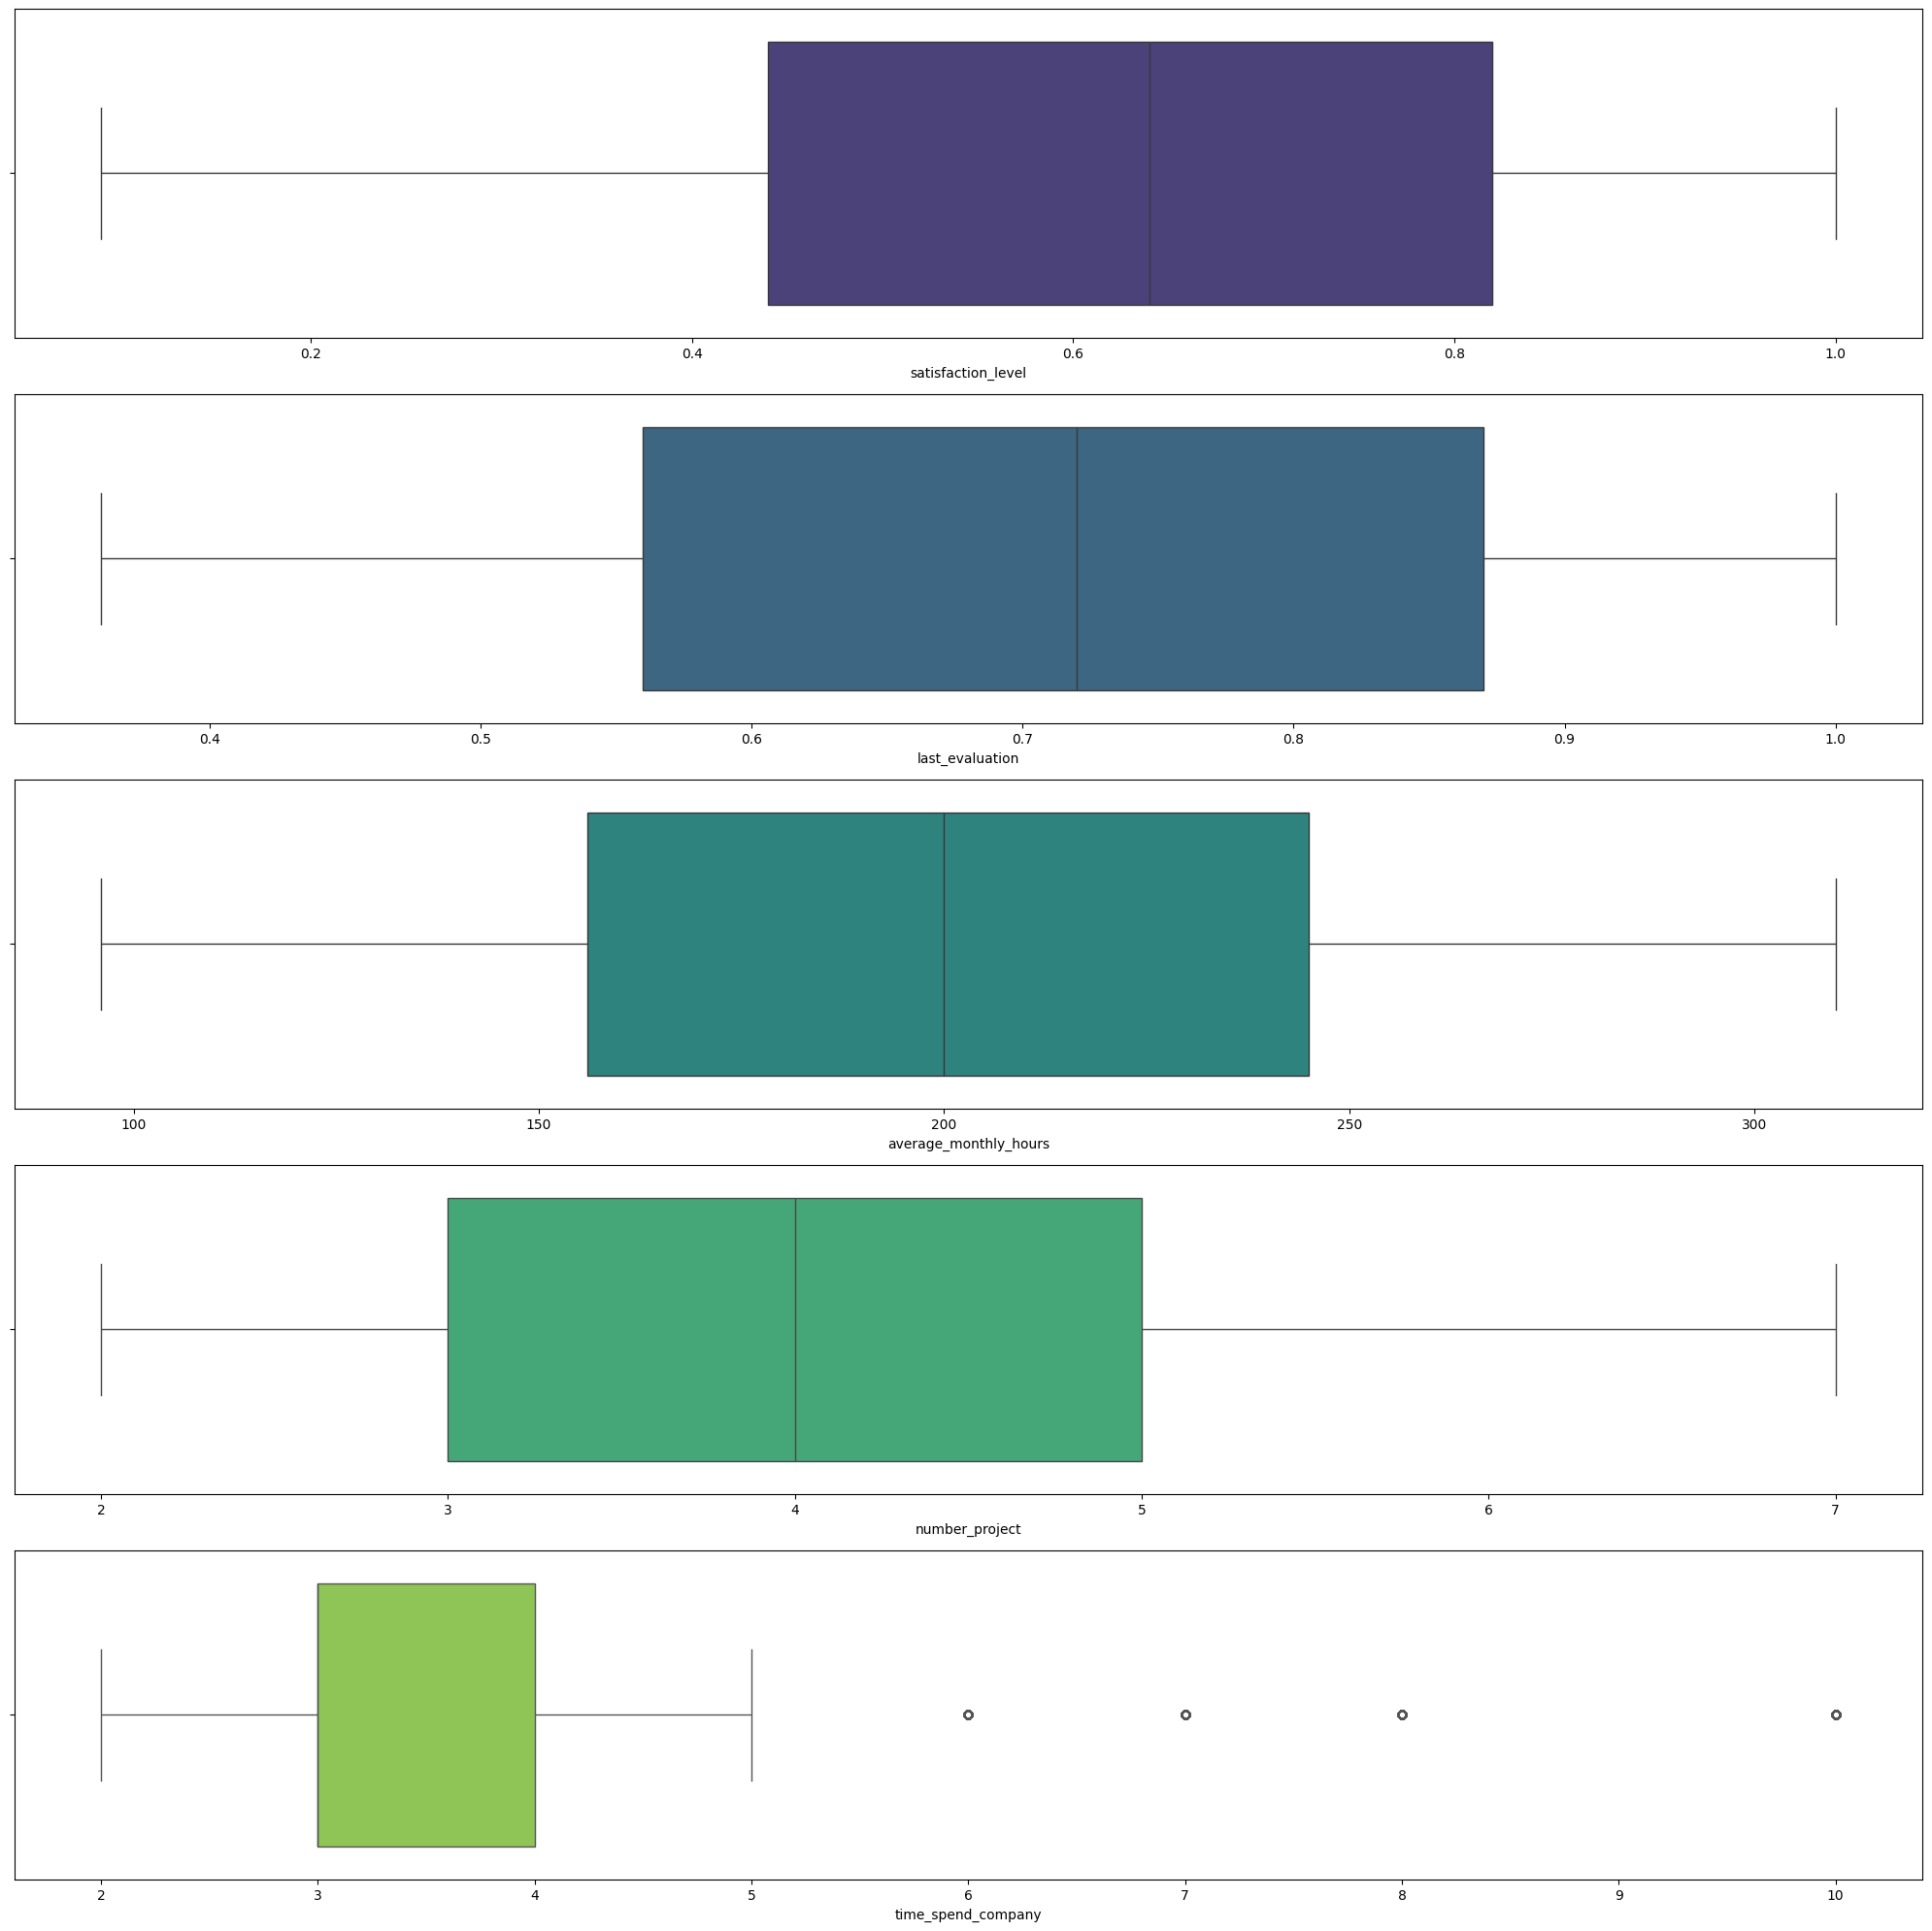

In [59]:
#Step 3 Exploratory Data Analysis (EDA), Search For Outliers
#Generate a viridis color palette with 5 distinct colors for the 5 boxplots
viridis_palette = sns.color_palette('viridis', n_colors=5)

fig, axs = plt.subplots(5, figsize=(20,20))
plt1= sns.boxplot(df_hr_encoded['satisfaction_level'], ax=axs[0], orient = 'h', color= viridis_palette[0])
plt2= sns.boxplot(df_hr_encoded['last_evaluation'], ax=axs[1], orient = 'h', color= viridis_palette[1])
plt3= sns.boxplot(df_hr_encoded['average_monthly_hours'], ax=axs[2], orient = 'h', color= viridis_palette[2])
plt4= sns.boxplot(df_hr_encoded['number_project'], ax=axs[3], orient = 'h', color= viridis_palette[3])
plt5= sns.boxplot(df_hr_encoded['time_spend_company'], ax=axs[4], orient = 'h', color= viridis_palette[4])
plt.tight_layout()

### Step 3 Continued: EDA - Correlation of 'left' with Numerical Features

This cell visualizes the relationship between employee turnover (`left`) and various numerical features using bar plots. It shows the average value of each numerical feature for employees who stayed (0) versus those who left (1), helping to identify potential drivers of turnover.

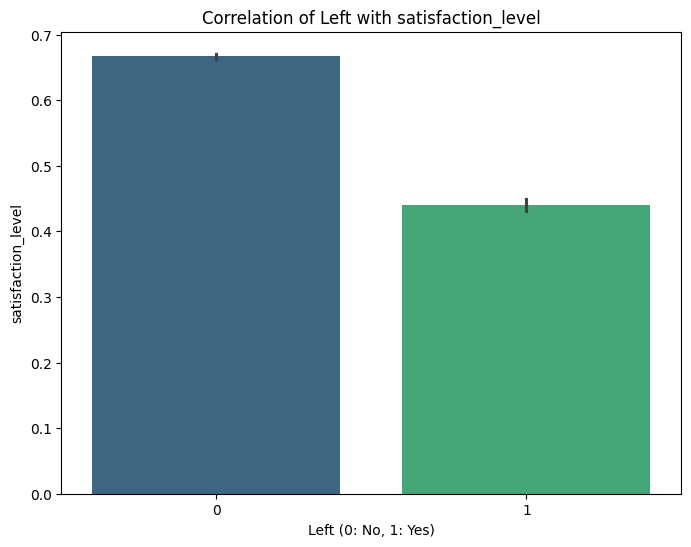

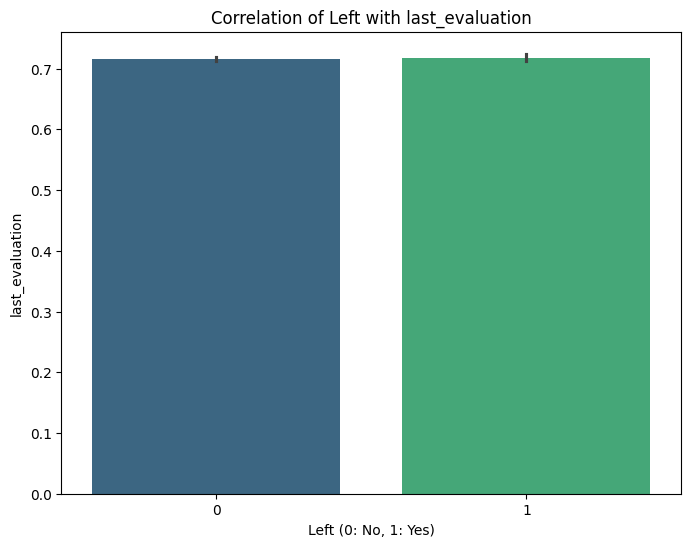

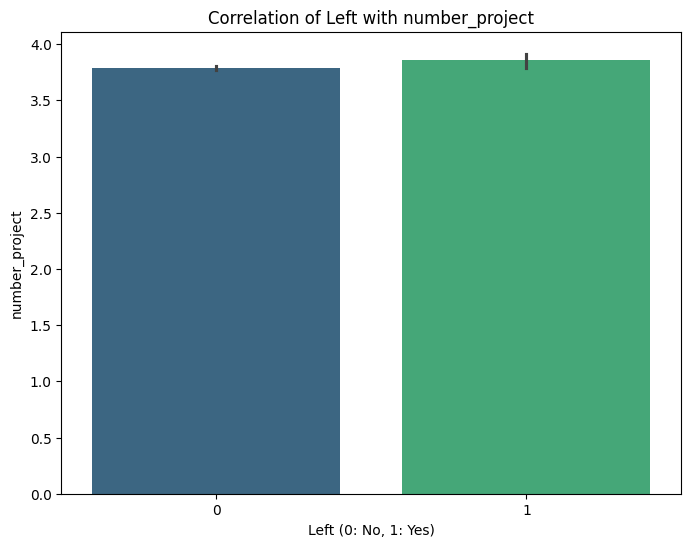

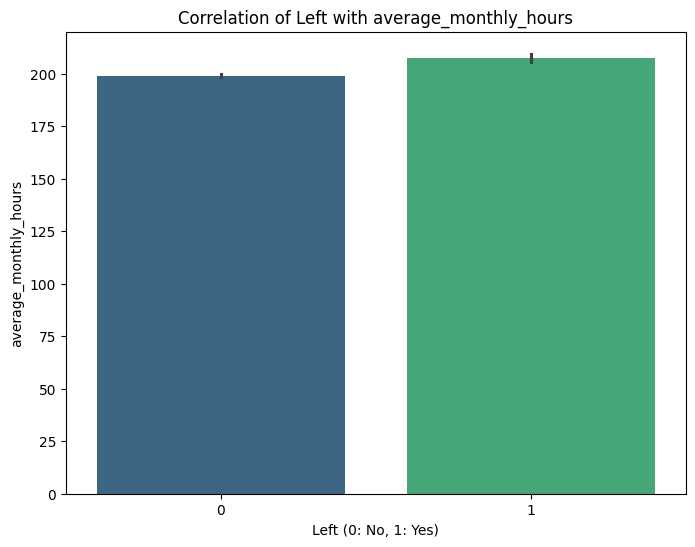

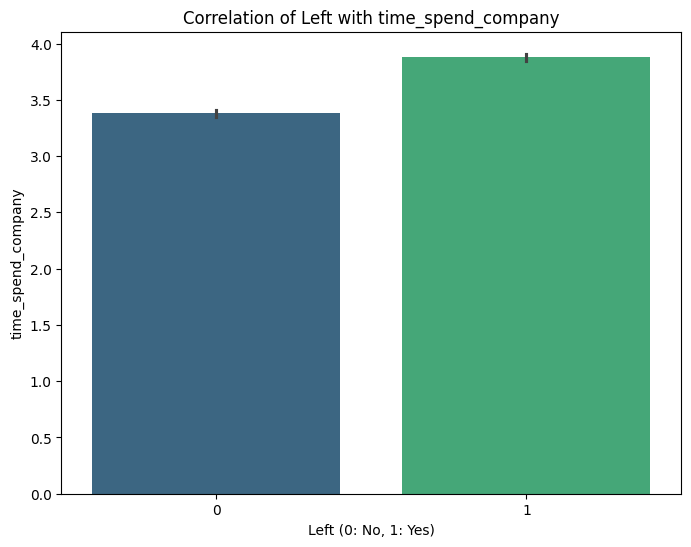

In [60]:
#Step 3: Exploratory Data Analysis (EDA) Continued
#Visualize the correlation of 'left' with numerical features using bar plots to view why employees are potentially leaving (or staying)
numerical_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spend_company']

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.barplot(x='left', y=col, data=df_hr_encoded, palette='viridis', hue='left', legend=False)
    plt.title(f'Correlation of Left with {col}')
    plt.xlabel('Left (0: No, 1: Yes)')
    plt.ylabel(col)
    plt.show()

### Step 3 Continued: EDA - Departmental Turnover View

This cell visualizes the relationship between employee turnover (`left`) and the encoded categorical features (departments and salary) using bar plots. This helps in understanding which departments or salary levels have higher or lower turnover rates.

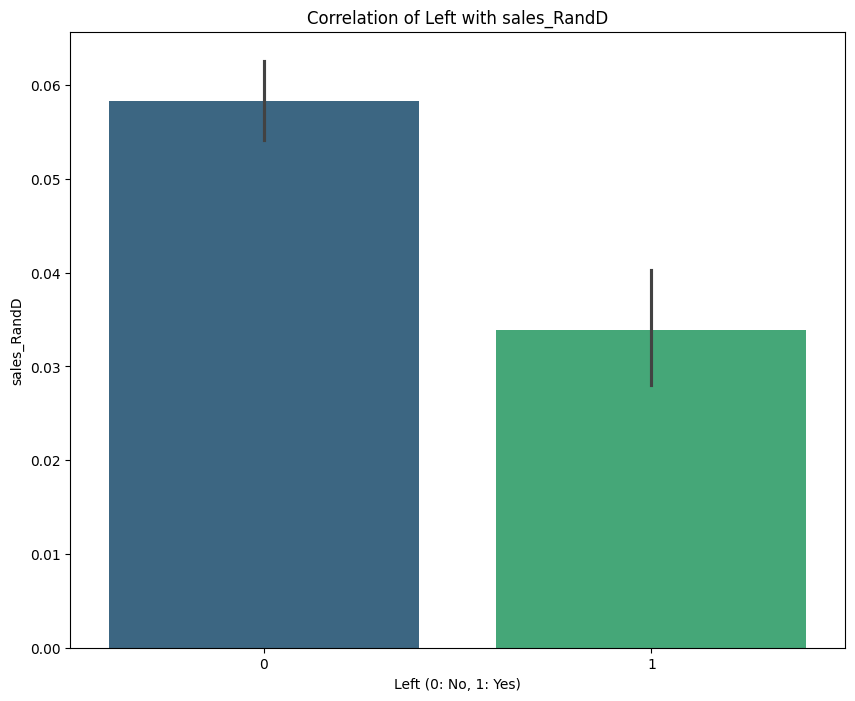

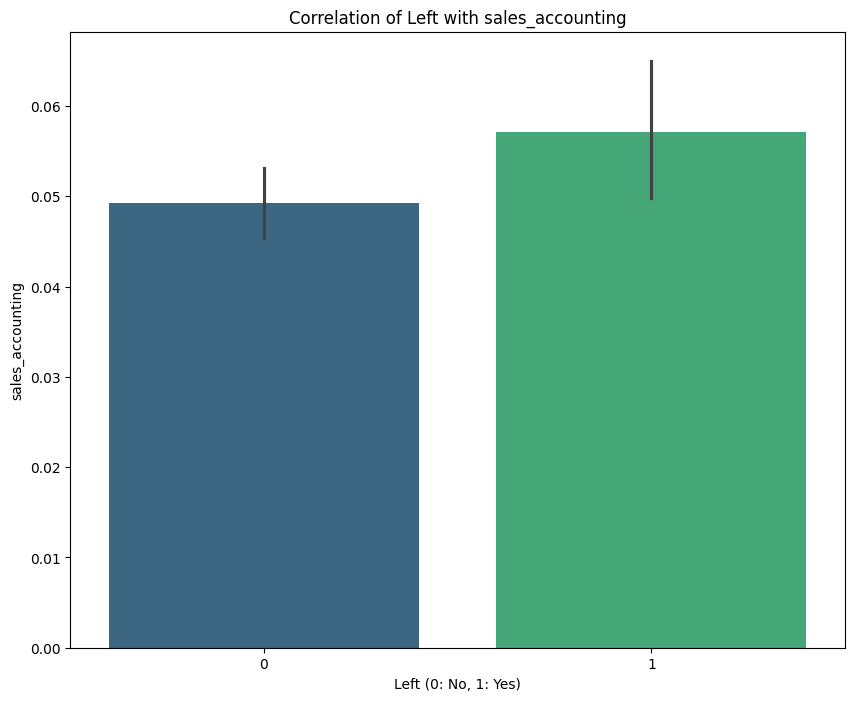

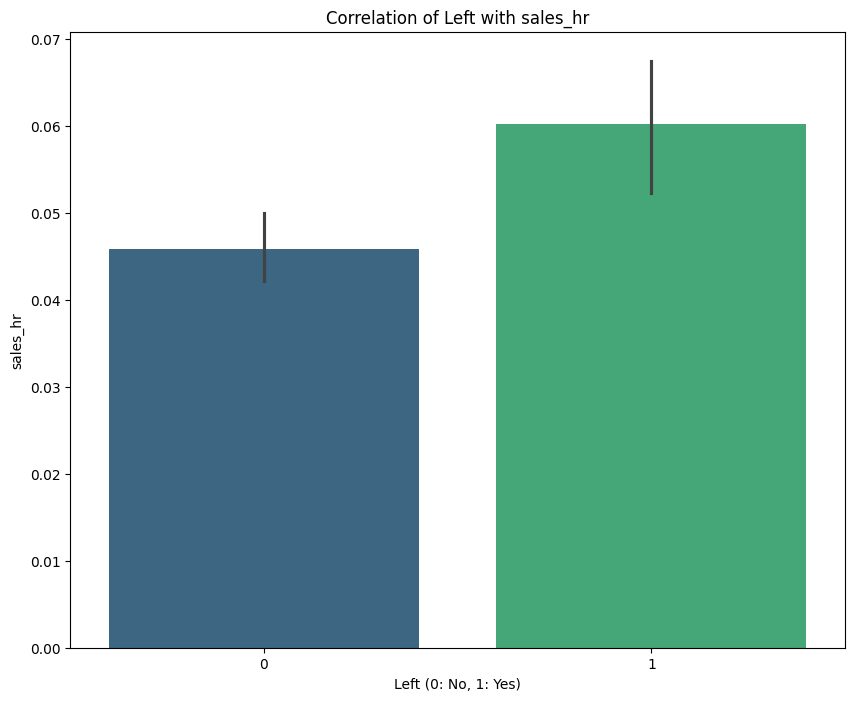

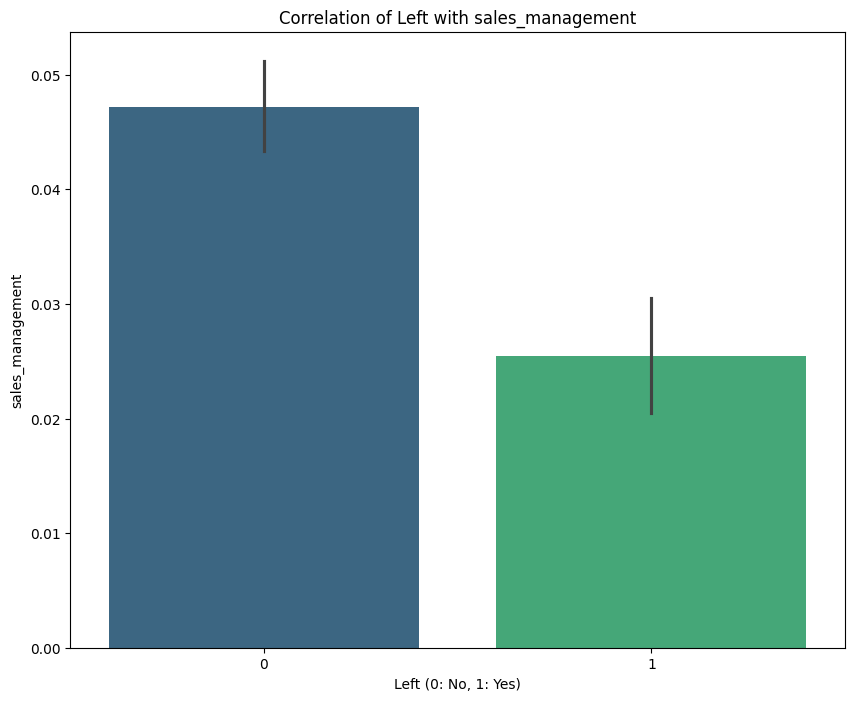

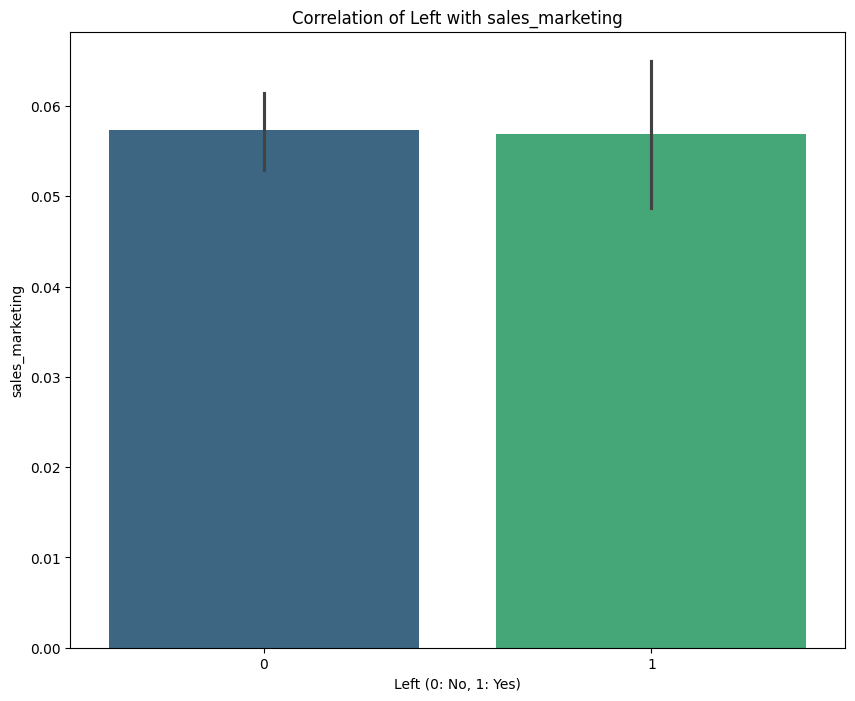

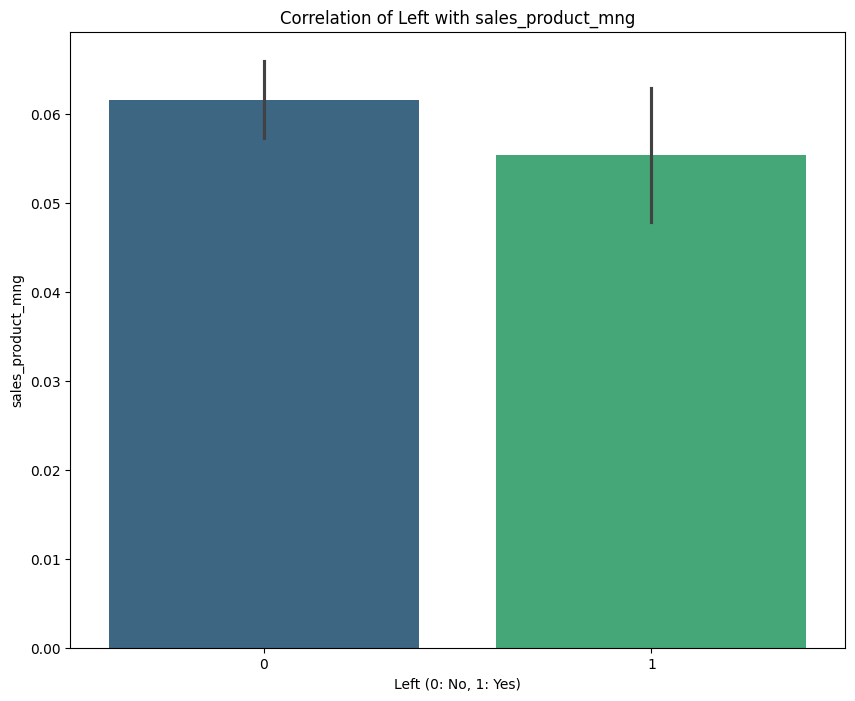

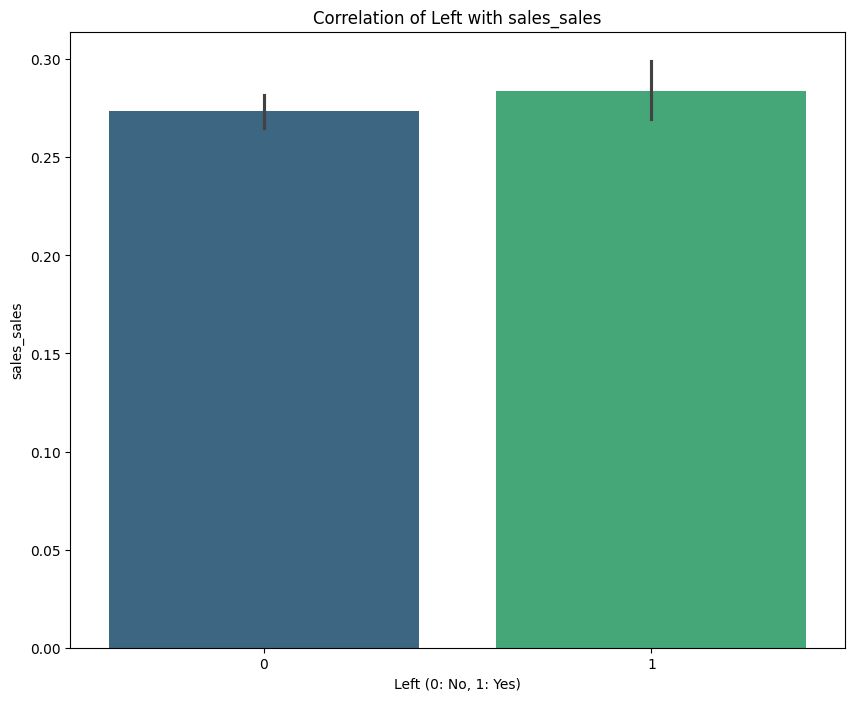

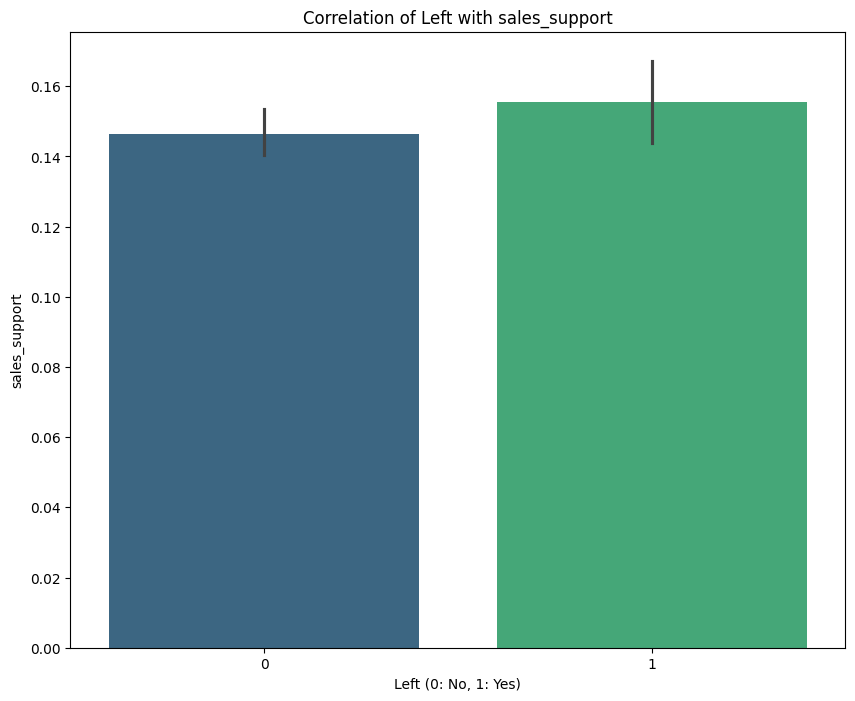

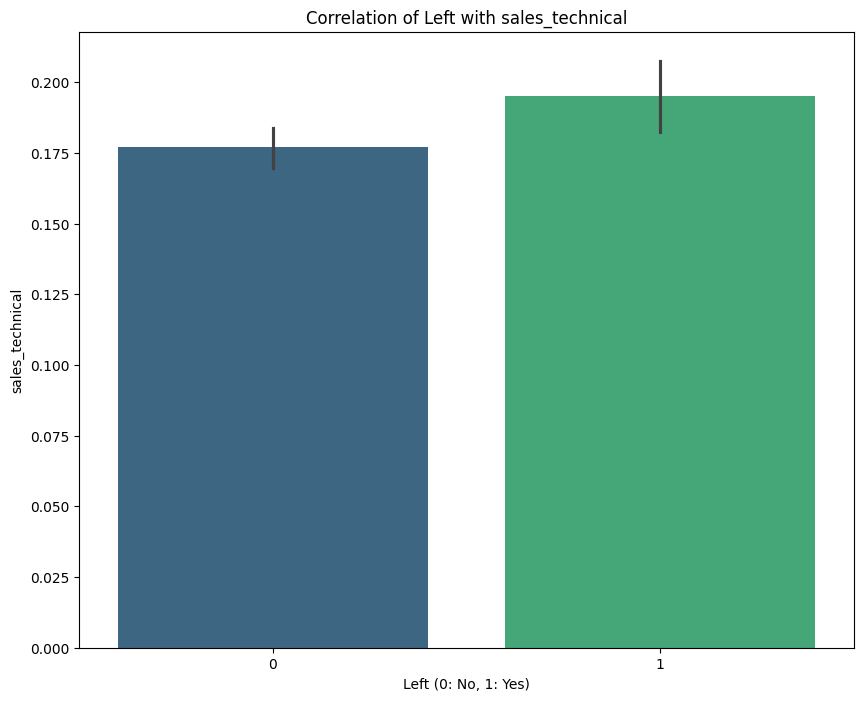

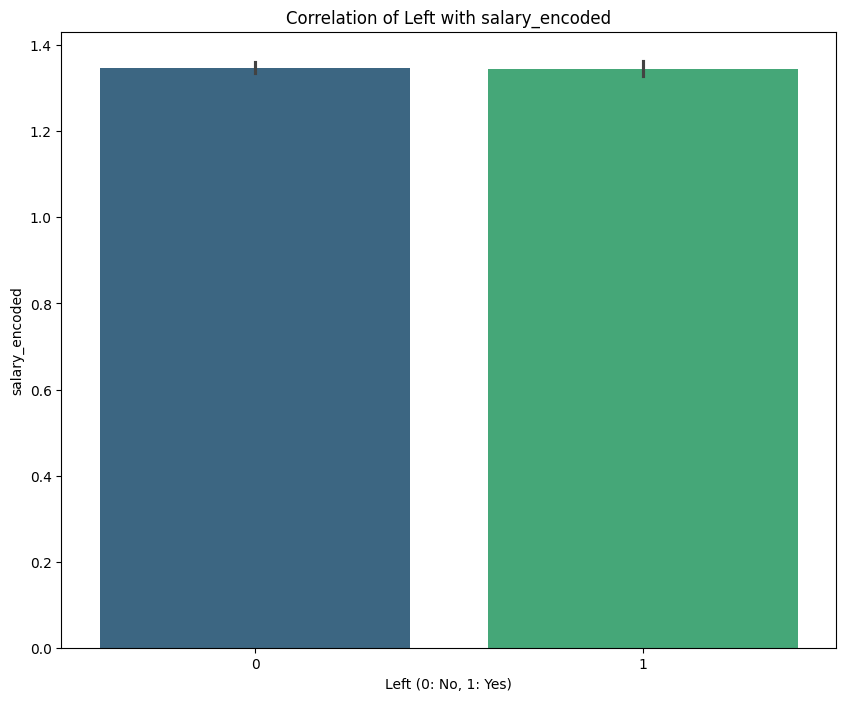

In [61]:
#Step 3 Continued: Departmental View
#Visualize the correlation of 'left' with encoded categorical features using bar plots to view turnover by department
encoded_categorical_cols = [col for col in df_hr_encoded.columns if col.startswith('sales_') or col == 'salary_encoded']

for col in encoded_categorical_cols:
    plt.figure(figsize=(10, 8))
    sns.barplot(x='left', y=col, data=df_hr_encoded, palette='viridis', hue='left', legend=False)
    plt.title(f'Correlation of Left with {col}')
    plt.xlabel('Left (0: No, 1: Yes)')
    plt.ylabel(col)
    plt.show()

### Step 3 Continued: EDA - Pair Plot for Selected Numerical Columns

This cell generates a pair plot for a selection of numerical columns, colored by the `left` variable. A pair plot helps visualize relationships between multiple variables and their distributions, providing insights into how different features interact with employee turnover.

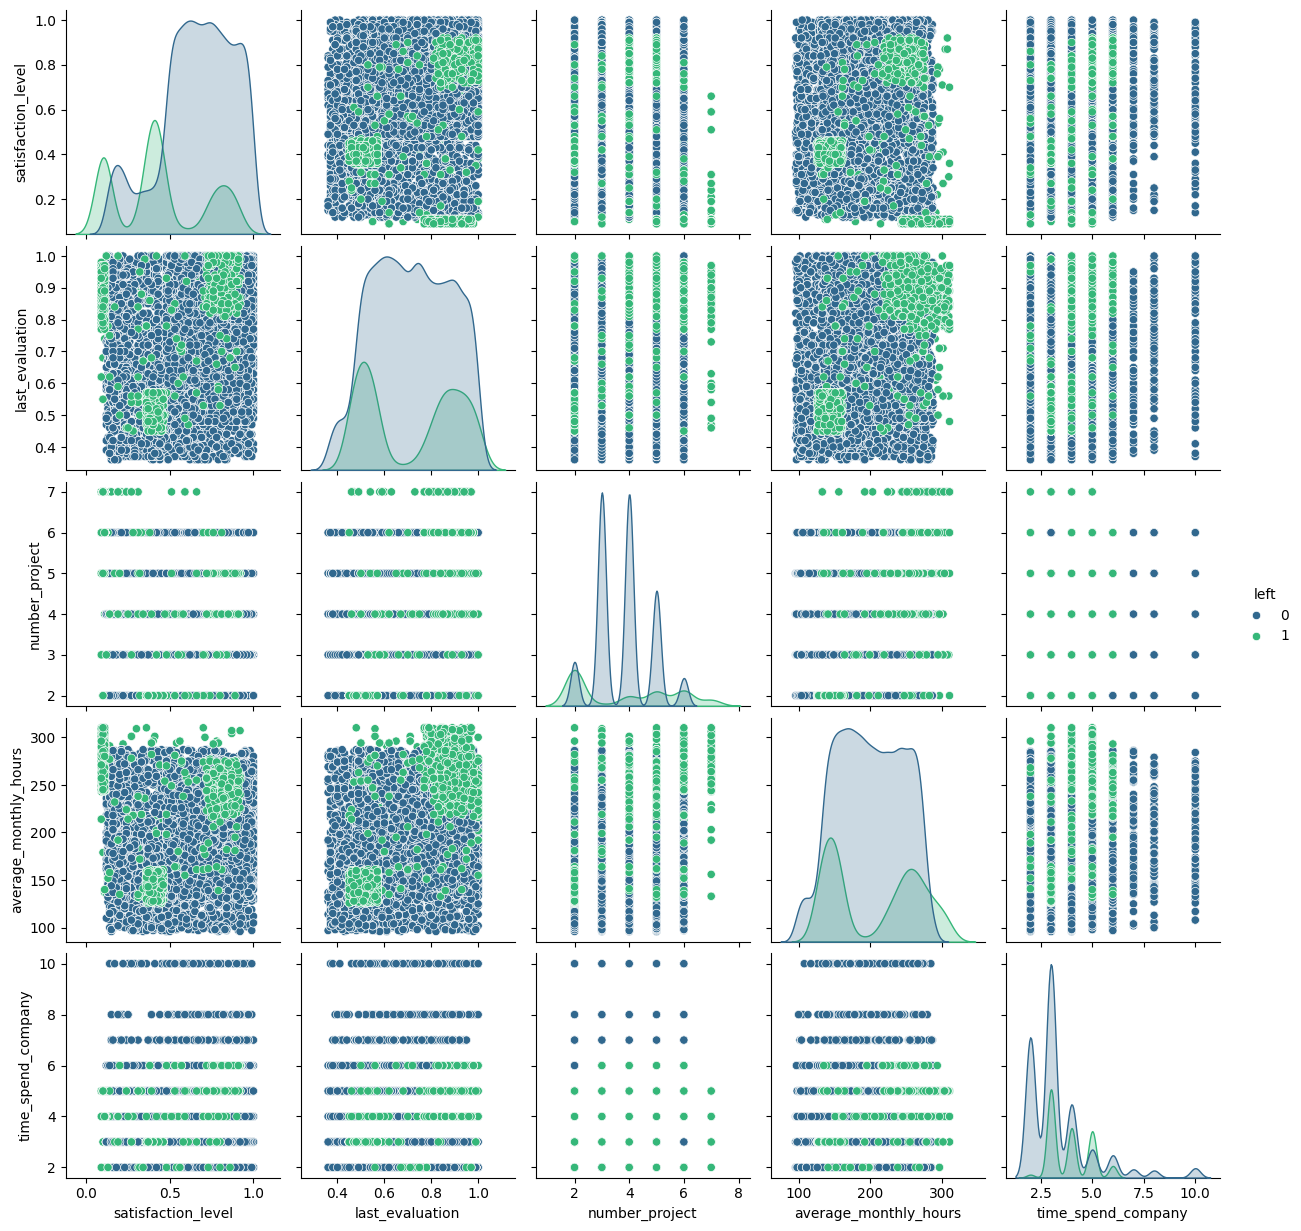

In [62]:
#Step 3 Continued
#Generate a pair plot for 'left' with selected numerical columns
selected_cols = ['left', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spend_company']
sns.pairplot(df_hr_encoded[selected_cols], hue='left', palette='viridis')
plt.show()

### Step 4: Feature Engineering - Creating 'engagement' and 'log_engagement'

This cell creates a new feature called `engagement` by multiplying `time_spend_company` and `number_project`. It also creates a `log_engagement` feature by applying a natural logarithm to the `engagement` values, which can help normalize its distribution. The head of the DataFrame is printed to show the new columns.

In [63]:
#Step 4: Feature Engineering
#Combine time_spend_company, number_project, and average_monthly_hours into a new feature called engagement
df_hr_encoded['engagement'] = df_hr_encoded['time_spend_company'] * df_hr_encoded['number_project']
print(df_hr_encoded.head())
log_engagement = np.log(df_hr_encoded['engagement'])
df_hr_encoded['log_engagement'] = log_engagement
print(df_hr_encoded.head())

   satisfaction_level  last_evaluation  number_project  average_monthly_hours  \
0                0.38             0.53               2                    157   
1                0.80             0.86               5                    262   
2                0.11             0.88               7                    272   
3                0.72             0.87               5                    223   
4                0.37             0.52               2                    159   

   time_spend_company  work_accident  left  promotion_last_5years  \
0                   3              0     1                      0   
1                   6              0     1                      0   
2                   4              0     1                      0   
3                   5              0     1                      0   
4                   3              0     1                      0   

   sales_RandD  sales_accounting  sales_hr  sales_management  sales_marketing  \
0        False   

### Visualize 'left' vs 'engagement'

This cell creates a bar plot to visualize the correlation between employee turnover (`left`) and the newly engineered `engagement` feature. It helps to understand if higher or lower engagement levels are associated with employees leaving the company.

<Axes: xlabel='left', ylabel='engagement'>

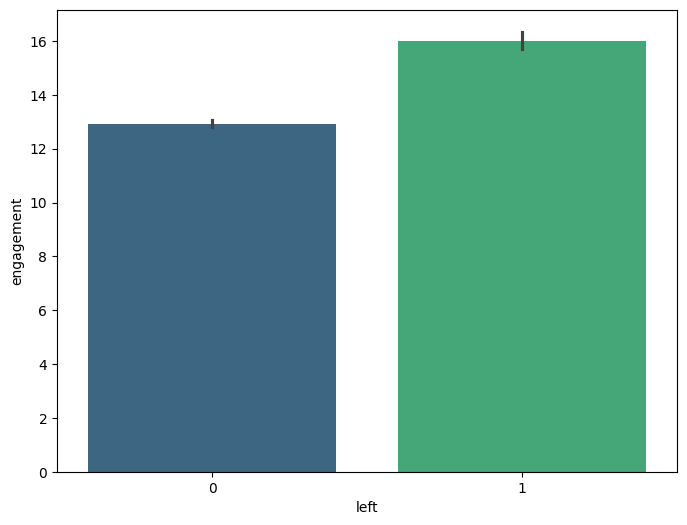

In [64]:
#Now see how 'left' correlates with 'engagement'
plt.figure(figsize=(8, 6))
sns.barplot(x='left', y='engagement', data=df_hr_encoded, palette='viridis', hue='left', legend=False)

### Visualize 'left' vs 'log_engagement'

This cell creates a bar plot to visualize the correlation between employee turnover (`left`) and the `log_engagement` feature. This is to see if the logarithmic transformation provides a clearer trend or relationship compared to the untransformed `engagement`.

<Axes: xlabel='left', ylabel='log_engagement'>

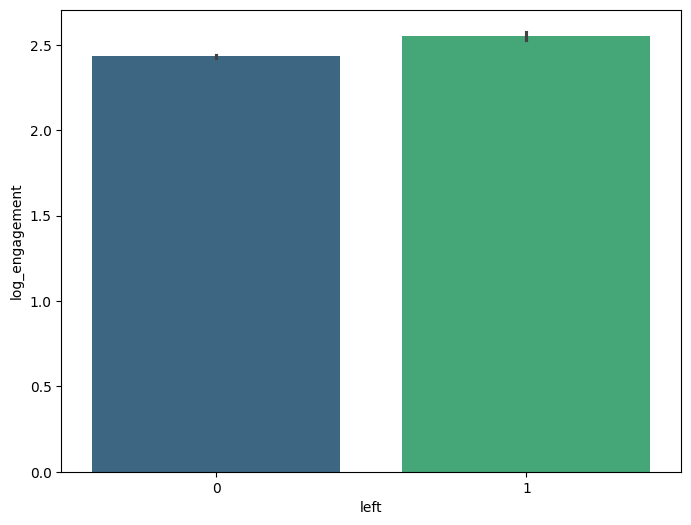

In [65]:
#Now see how 'left' correlates with 'log_engagement'
plt.figure(figsize=(8, 6))
sns.barplot(x='left', y='log_engagement', data=df_hr_encoded, palette='viridis', hue='left', legend=False)

### Generate Histograms for Numerical Columns

This cell generates histograms for all numerical columns in the `df_hr_encoded` DataFrame. Histograms provide a visual representation of the distribution of each variable, helping to identify skewness, peaks, and potential anomalies.

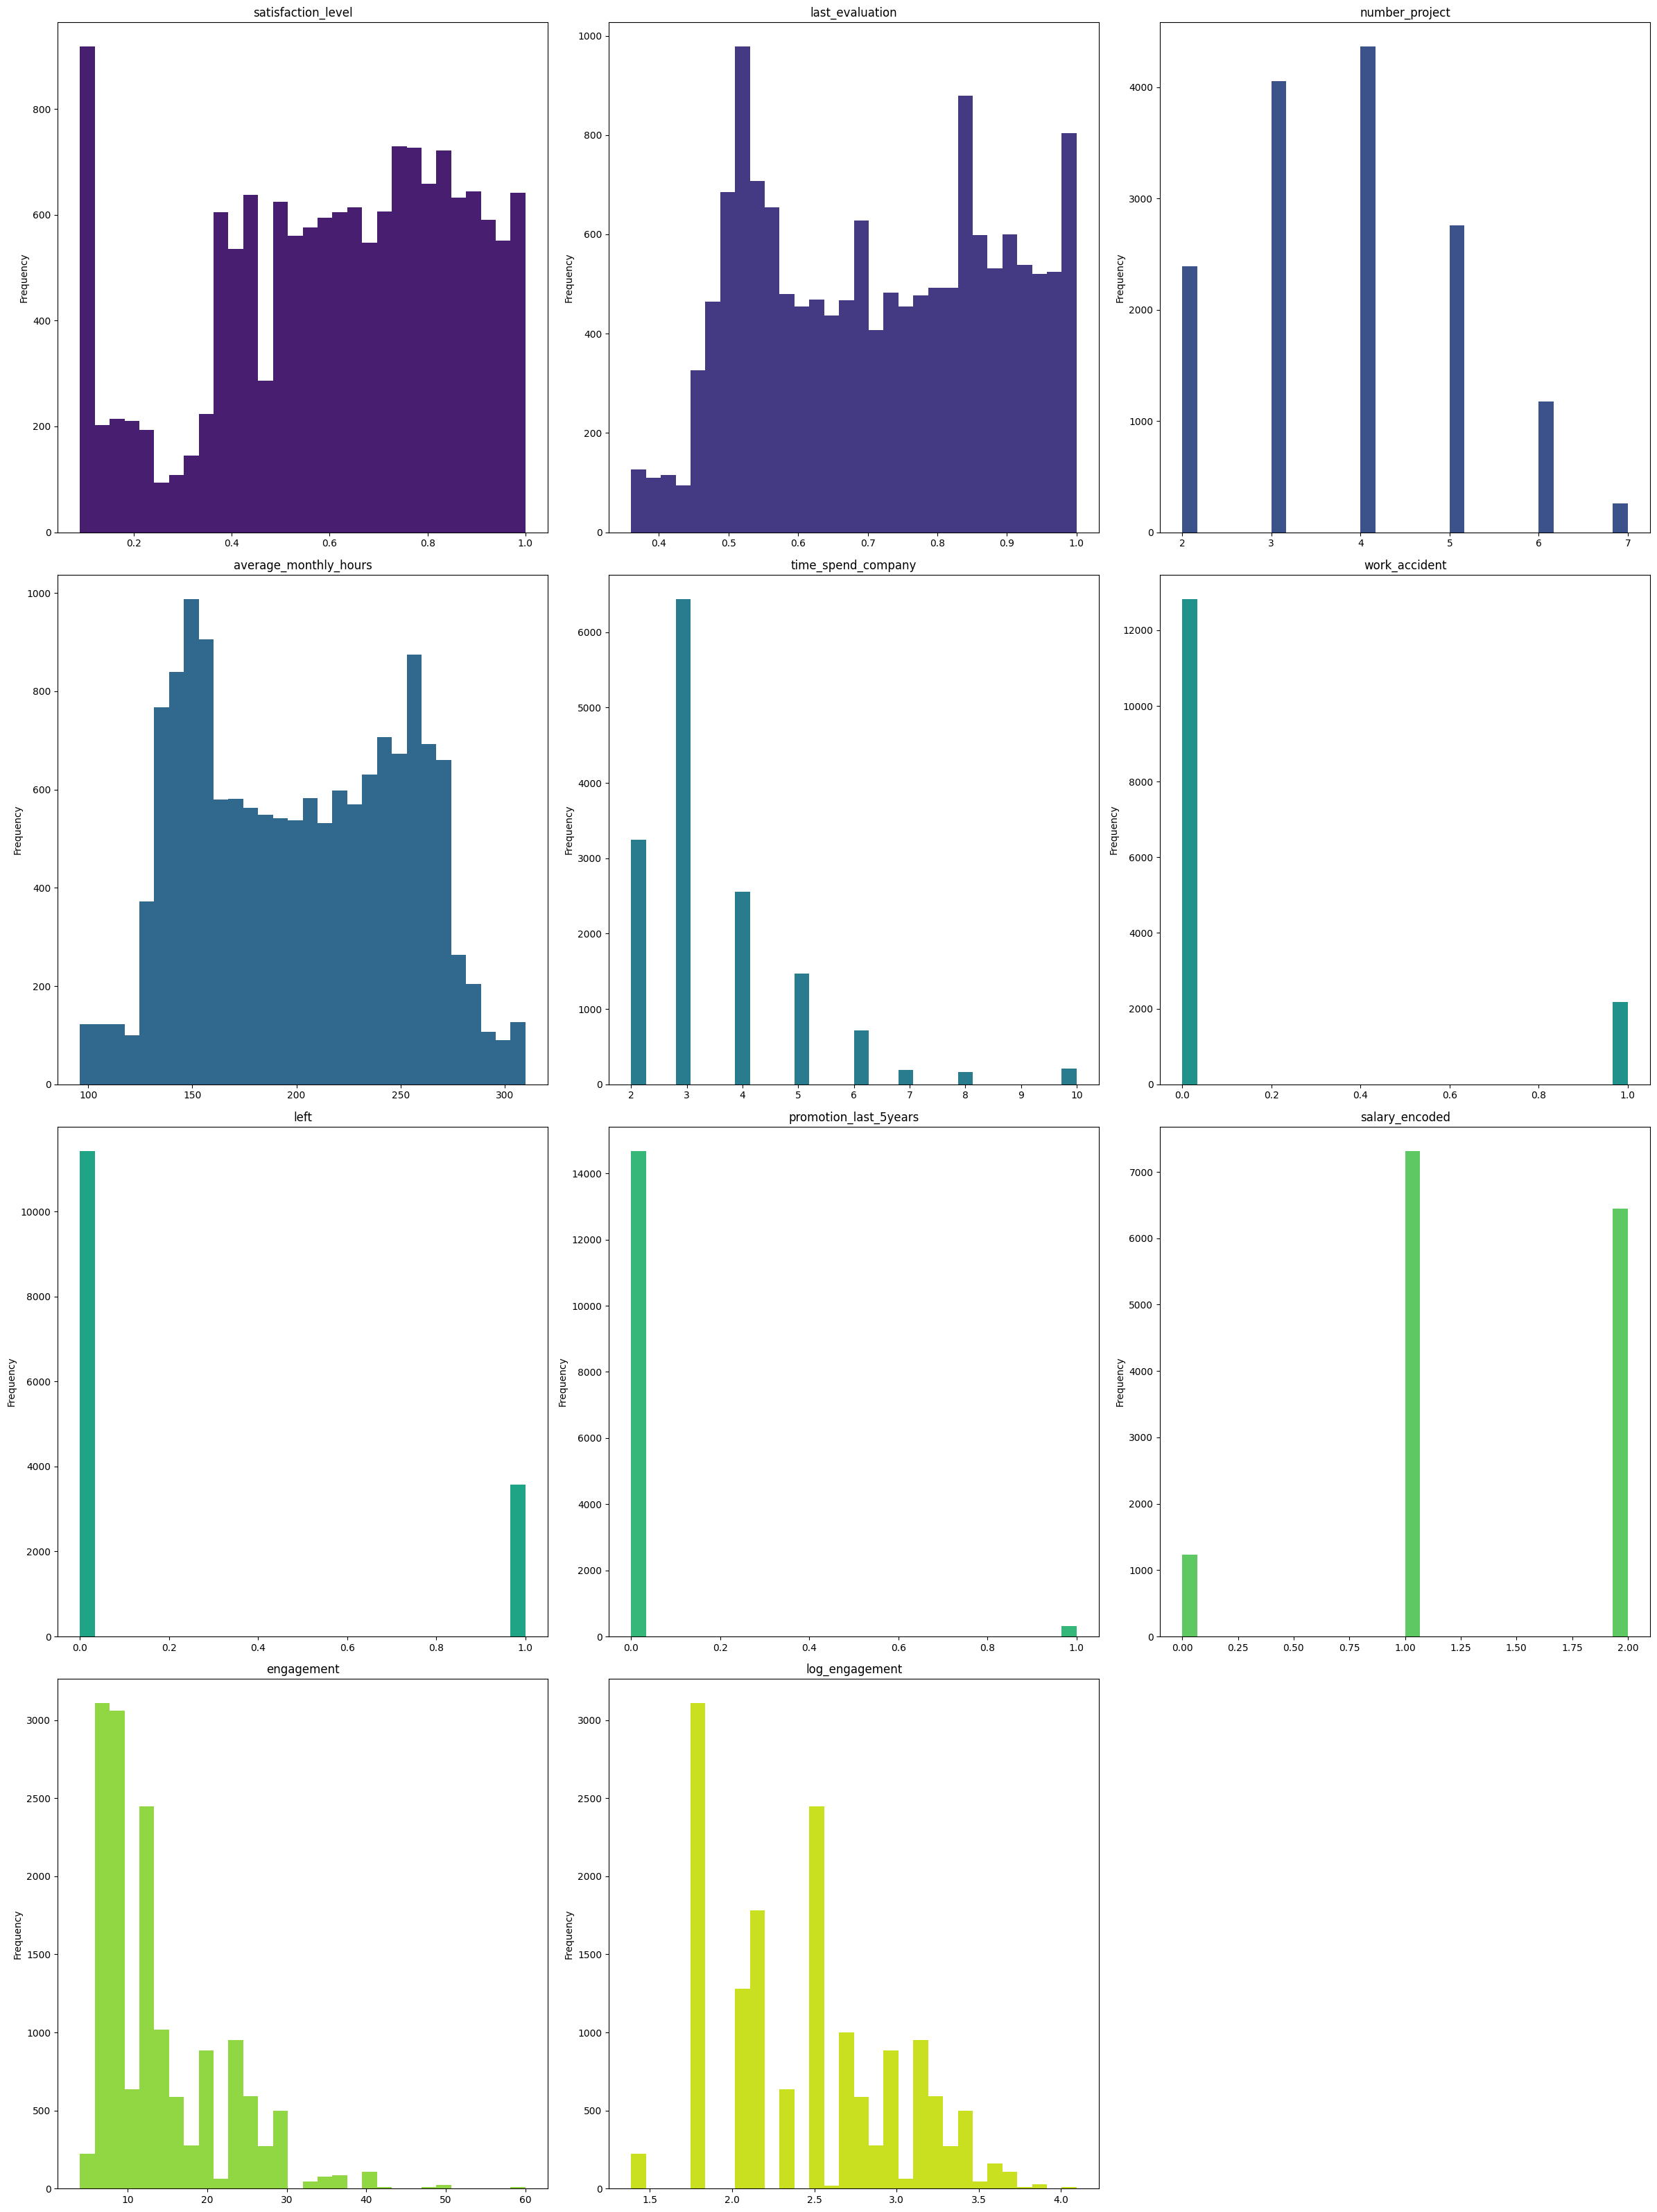

In [66]:
#Generate histograms for all numerical columns
numerical_cols = df_hr_encoded.select_dtypes(include=np.number).columns
n_cols = len(numerical_cols)

#Create a viridis color palette with enough colors for all histograms
viridis_palette = sns.color_palette('viridis', n_colors=n_cols)

#Calculate optimal grid size for subplots
n_rows = int(np.ceil(n_cols / 3)) #Max 3 columns of plots
fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(24, n_rows * 8))
axes = axes.flatten() #Flatten the 2D array of axes for easier iteration

for i, col in enumerate(numerical_cols):
    if i < len(axes): #Ensure you don't go out of bounds if there are more columns than subplots available
        axes[i].hist(df_hr_encoded[col], bins=30, color=viridis_palette[i])
        axes[i].set_title(col)
        axes[i].set_ylabel('Frequency')

#Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Generate Correlation Matrix Heatmap

This cell calculates the correlation matrix for all features in `df_hr_encoded` and visualizes it as a heatmap. The heatmap shows the pairwise correlation coefficients between variables, highlighting strong positive or negative relationships, which can be useful for feature selection or understanding multicollinearity.

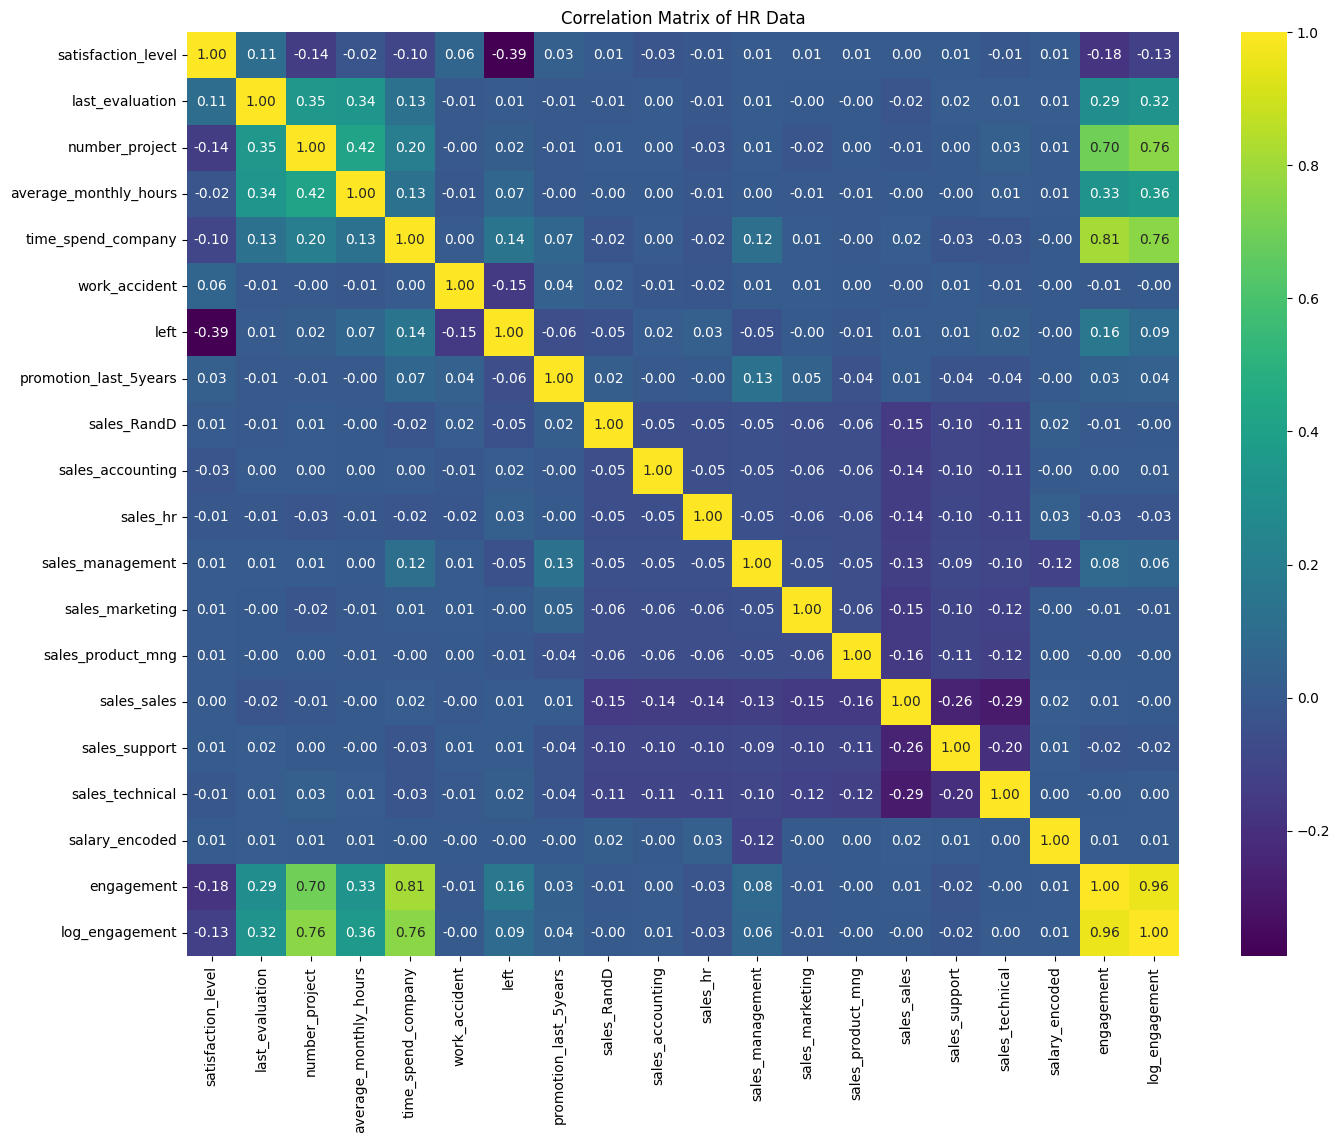

In [67]:
correlation_matrix = df_hr_encoded.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix of HR Data')
plt.show()

### Step 5: Model Training and Evaluation

This section initiates machine learning model development. It includes `train_test_split` for data partitioning, `StandardScaler` for feature scaling, `SVC` for Support Vector Machines, `DecisionTreeClassifier`, `RandomForestClassifier`, and `accuracy_score`, `classification_report` for model evaluation.

### Split Data into Training and Testing Sets

This cell splits the prepared dataset into training and testing sets. `X` contains the features (all columns except 'left'), and `y` contains the target variable ('left'). The data is split into an 80% training set and a 20% testing set, with `random_state` for reproducibility.

In [68]:
#Split the data at an 80/20 ratio of train/test
X = df_hr_encoded.drop('left', axis=1)
y = df_hr_encoded['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

### Scale Numerical Features

This cell scales the numerical features in the training and testing sets using `StandardScaler`. This process transforms the data to have zero mean and unit variance, which is crucial for models like SVMs and can improve the performance of other models. The scaled `X_train` and `X_test` are then displayed.

In [69]:
#Scale the numerical columns/features for a better machine learning view using StandardScaler
numerical_cols = X_train.select_dtypes(include=np.number).columns

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())
display(X_test.head())

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_encoded,engagement,log_engagement
9838,1.555391,-0.619346,-0.653412,-0.260887,0.340617,-0.411003,-0.149989,False,False,False,False,False,True,False,False,False,-0.558136,-0.210193,0.038375
7689,-1.818394,0.372007,0.156954,-0.100652,1.024071,-0.411003,-0.149989,False,False,False,False,False,False,False,False,True,-2.156864,0.788116,0.978537
6557,0.752109,0.488637,-0.653412,-0.521269,-1.026293,-0.411003,-0.149989,True,False,False,False,False,False,False,False,False,1.040592,-0.958924,-1.237347
6872,0.189811,0.838527,0.156954,-1.783117,1.707526,-0.411003,-0.149989,False,True,False,False,False,False,False,False,False,1.040592,1.287271,1.314096
820,-2.019214,1.246731,2.588050,1.661929,0.340617,-0.411003,-0.149989,False,False,False,False,False,False,False,False,True,-0.558136,1.786425,1.597807


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_encoded,engagement,log_engagement
6723,0.149647,1.421676,0.967319,0.500228,-1.026293,2.433072,-0.149989,False,False,False,False,True,False,False,False,False,1.040592,-0.459770,-0.297184
6473,1.073422,0.488637,-0.653412,-0.701533,-1.026293,-0.411003,-0.149989,False,False,False,False,False,False,False,False,False,-0.558136,-0.958924,-1.237347
4679,0.310304,1.538306,-0.653412,0.259876,-1.026293,-0.411003,-0.149989,False,False,False,False,False,False,True,False,False,-0.558136,-0.958924,-1.237347
862,-0.814291,-1.435755,-1.463777,-0.941885,-0.342838,-0.411003,-0.149989,False,False,False,False,False,False,True,False,False,-0.558136,-0.958924,-1.237347
7286,1.033257,0.255377,0.967319,1.061049,-1.026293,2.433072,-0.149989,False,False,True,False,False,False,False,False,False,-0.558136,-0.459770,-0.297184


### Initialize Classification Models

This cell initializes three different classification models: Support Vector Classifier (SVC), Decision Tree Classifier, and Random Forest Classifier. These models will be used to predict employee turnover.

In [70]:
#Run all 3 models (SVM, Decision Tree, and Random Forest)
svm_model = SVC()
decision_tree_model = DecisionTreeClassifier()
random_forest_model = RandomForestClassifier()

### Cross-Validate Models

This cell performs k-fold cross-validation (with 5 splits) on the three initialized models using `StratifiedKFold`. Cross-validation helps assess the models' generalization performance and robustness by training and testing them on different subsets of the training data. The accuracy scores for each fold are printed.

In [71]:
#Cross validate the models with k-folds and and train them with the training data

n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

svm_scores = cross_val_score(svm_model, X_train, y_train, cv=kfold, scoring='accuracy')
decision_tree_scores = cross_val_score(decision_tree_model, X_train, y_train, cv=kfold, scoring='accuracy')
random_forest_scores = cross_val_score(random_forest_model, X_train, y_train, cv=kfold, scoring='accuracy')

print("SVM Cross-Validation Scores:", svm_scores)
print("Decision Tree Cross-Validation Scores:", decision_tree_scores)
print("Random Forest Cross-Validation Scores:", random_forest_scores)

SVM Cross-Validation Scores: [0.96541667 0.95916667 0.96333333 0.96125    0.96206753]
Decision Tree Cross-Validation Scores: [0.97583333 0.98125    0.985      0.97625    0.97707378]
Random Forest Cross-Validation Scores: [0.99125    0.99125    0.99291667 0.98791667 0.98999583]


### Train Models and Evaluate on Test Set

This cell trains each of the three models (SVM, Decision Tree, Random Forest) on the entire training dataset (`X_train`, `y_train`). It then makes predictions on the unseen test set (`X_test`) and evaluates their performance using `accuracy_score` and `classification_report`, which provides precision, recall, and F1-score for each class.

In [72]:
#Evaluate all 3 model fits on accuracy, precision, recall, and F1 score
svm_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
decision_tree_pred = decision_tree_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, decision_tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, random_forest_pred))

print("\nSVM Classification Report:\n", classification_report(y_test, svm_pred))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, decision_tree_pred))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, random_forest_pred))

SVM Accuracy: 0.9596666666666667
Decision Tree Accuracy: 0.975
Random Forest Accuracy: 0.988

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      2294
           1       0.93      0.89      0.91       706

    accuracy                           0.96      3000
   macro avg       0.95      0.94      0.94      3000
weighted avg       0.96      0.96      0.96      3000


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      2294
           1       0.93      0.96      0.95       706

    accuracy                           0.97      3000
   macro avg       0.96      0.97      0.97      3000
weighted avg       0.98      0.97      0.98      3000


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96    

### View Model Performance and Select Best Model

This cell reiterates the performance metrics (accuracy and classification reports) for each model. Based on these metrics, it explicitly identifies the Random Forest model as the best-performing model due to its highest accuracy and strong precision, recall, and F1-scores across both classes.

In [73]:
#View the results and select the best model
print("Model Performance Metrics:")
print("--------------------------")

#Assuming accuracy scores and classification reports from the previous step are available
#Re-print the accuracy scores for clarity
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, decision_tree_pred):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, random_forest_pred):.4f}")

print("\nSVM Classification Report:\n", classification_report(y_test, svm_pred))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, decision_tree_pred))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, random_forest_pred))

print("\nBased on the evaluation:")
print("The Random Forest model performed the best.")
print("It achieved the highest accuracy and generally better precision, recall, and F1-score across both classes compared to the SVM and Decision Tree models.")

Model Performance Metrics:
--------------------------
SVM Accuracy: 0.9597
Decision Tree Accuracy: 0.9750
Random Forest Accuracy: 0.9880

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      2294
           1       0.93      0.89      0.91       706

    accuracy                           0.96      3000
   macro avg       0.95      0.94      0.94      3000
weighted avg       0.96      0.96      0.96      3000


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      2294
           1       0.93      0.96      0.95       706

    accuracy                           0.97      3000
   macro avg       0.96      0.97      0.97      3000
weighted avg       0.98      0.97      0.98      3000


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    

### Step 6: Final Model Training

This cell trains the selected best model, the Random Forest Classifier, on the entire training set. This is the final step before evaluating its performance on the completely unseen test set.

In [74]:
#Step 6: Final model training using the entire training set
#Train the best model (Random Forest) on the entire training set
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
print("Final Random Forest model trained on the entire training set.")

Final Random Forest model trained on the entire training set.


### Step 7: Final Model Testing

This cell evaluates the performance of the finally trained Random Forest model on the dedicated test set. It generates a classification report to provide a comprehensive view of the model's precision, recall, and F1-score for predicting employee turnover.

In [75]:
#Step 7: Final model testing on the entire testing set
#Evaluate the final model on the test set
final_pred = best_model.predict(X_test)

print("Final Random Forest Model Classification Report on Test Set:\n", classification_report(y_test, final_pred))

Final Random Forest Model Classification Report on Test Set:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

